# Контроль качества данных

Ноутбук проверяет воспроизводимость снимка, структуру рядов и базовые свойства доходностей. Сырые файлы в `data/raw` не изменяются.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from analysis.loading import load_raw_snapshot  # noqa: E402
from analysis.quality import (  # noqa: E402
    add_log_returns,
    build_quality_report,
    shared_calendar,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
TRADING_DAYS_PER_YEAR = 252

## Загрузка проверенного снимка

`load_raw_snapshot` сверяет `prices.csv` с числом строк, размером и SHA-256 из манифеста до начала анализа.

In [2]:
snapshot = load_raw_snapshot(PROJECT_ROOT / "data/raw")
prices = snapshot.prices
metadata = pd.Series(
    {
        "created_at_utc": snapshot.metadata.created_at_utc,
        "tickers": ", ".join(snapshot.metadata.tickers),
        "start": snapshot.metadata.start,
        "end_exclusive": snapshot.metadata.end,
        "interval": snapshot.metadata.interval,
        "source": snapshot.metadata.source,
        "rows": len(prices),
    },
    name="value",
).to_frame()
metadata

,value
created_at_utc,2026-09-11T05:36:16.316404+00:00
tickers,"SPY, AAPL, JPM, XOM"
start,2006-01-03
end_exclusive,2026-01-01
interval,1d
source,Yahoo Finance via yfinance
rows,20124


## Структура и качество рядов

In [3]:
quality_report = build_quality_report(prices)
calendars_match = shared_calendar(prices)

assert quality_report["missing_values"].sum() == 0
assert quality_report["duplicate_dates"].sum() == 0
assert calendars_match

print(f"Общий торговый календарь: {calendars_match}")
quality_report

Общий торговый календарь: True


,ticker,observations,first_date,last_date,missing_values,duplicate_dates,dividend_events,split_events
0,AAPL,5031,2006-01-03,2025-12-31,0,0,54,2
1,JPM,5031,2006-01-03,2025-12-31,0,0,80,0
2,SPY,5031,2006-01-03,2025-12-31,0,0,80,0
3,XOM,5031,2006-01-03,2025-12-31,0,0,80,0


In [4]:
prices.dtypes.to_frame("dtype")

,dtype
date,datetime64[ns]
ticker,object
open,float64
high,float64
low,float64
close,float64
adj_close,float64
volume,int64
dividends,float64
stock_splits,int64


## Скорректированные цены

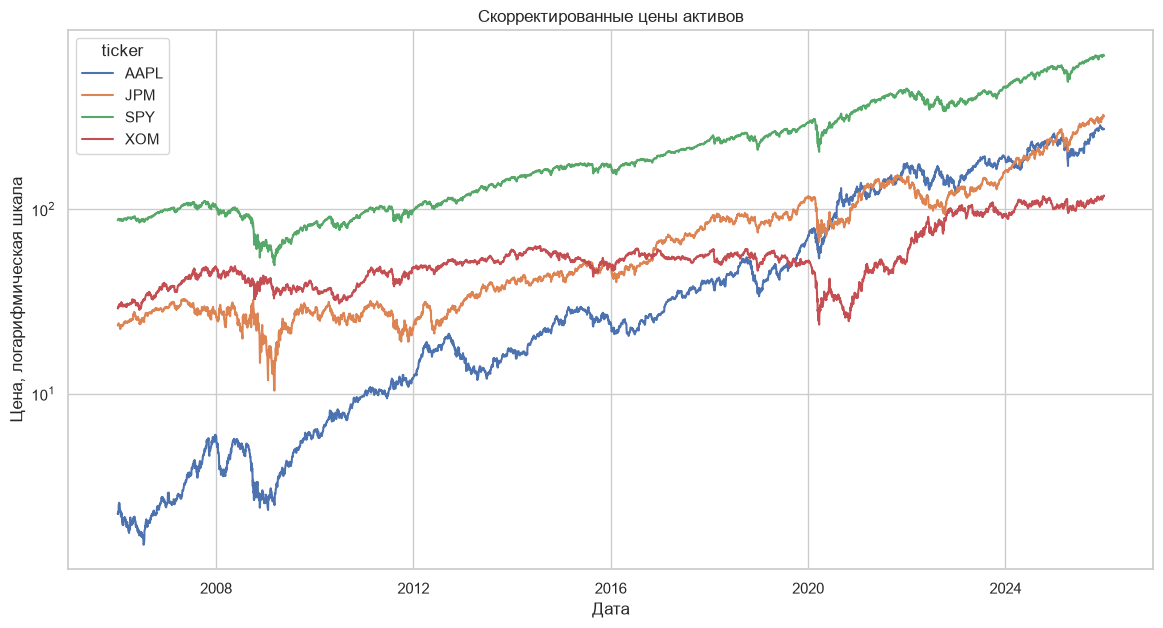

In [5]:
figure, axis = plt.subplots(figsize=(14, 7))
sns.lineplot(data=prices, x="date", y="adj_close", hue="ticker", ax=axis)
axis.set(
    title="Скорректированные цены активов",
    xlabel="Дата",
    ylabel="Цена, логарифмическая шкала",
)
axis.set_yscale("log")
plt.show()

## Логарифмические доходности

Доходности рассчитываются отдельно внутри каждого актива: $r_t = \log(P_t / P_{t-1})$.

In [6]:
returns = add_log_returns(prices)
return_statistics = (
    returns.groupby("ticker")["log_return"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .assign(annualized_volatility=lambda frame: frame["std"] * np.sqrt(TRADING_DAYS_PER_YEAR))
)
return_statistics

,count,mean,std,min,median,max,annualized_volatility
ticker,,,,,,,
AAPL,5030,0.000954,0.020016,-0.197470,0.000986,0.142618,0.317752
JPM,5030,0.000517,0.022960,-0.232278,0.000530,0.223917,0.364475
SPY,5030,0.000408,0.012221,-0.115886,0.000701,0.135577,0.193999
XOM,5030,0.000279,0.016747,-0.150271,0.000284,0.158631,0.265843


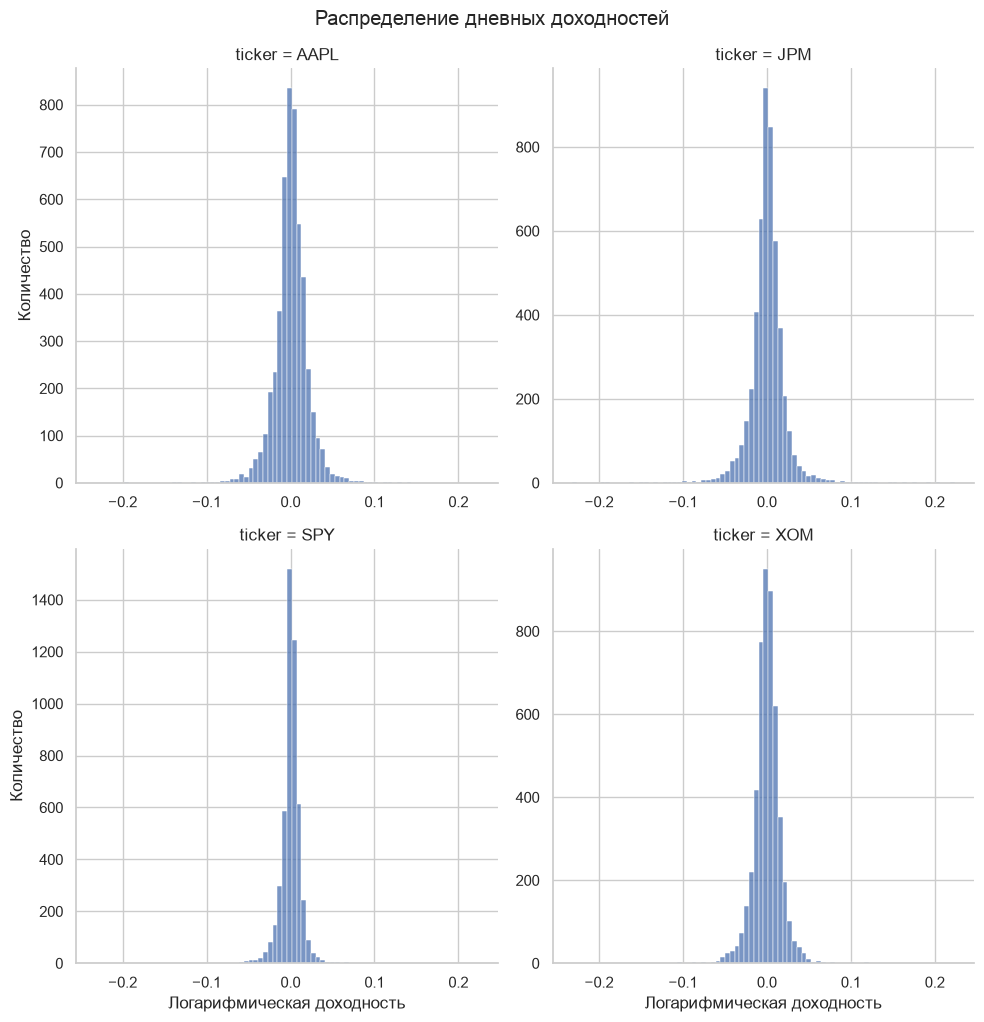

In [7]:
distribution = returns.dropna(subset=["log_return"])
grid = sns.displot(
    data=distribution,
    x="log_return",
    col="ticker",
    col_wrap=2,
    bins=80,
    facet_kws={"sharex": False, "sharey": False},
)
grid.set_axis_labels("Логарифмическая доходность", "Количество")
grid.figure.suptitle("Распределение дневных доходностей", y=1.02)
plt.show()

## Волатильность и экстремальные движения

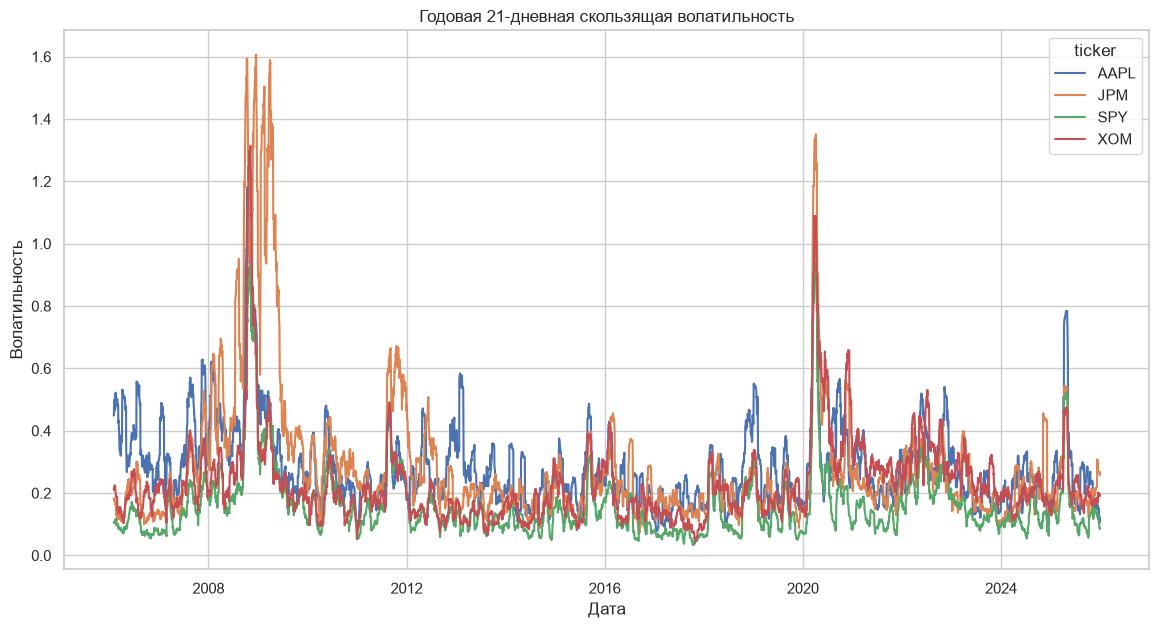

In [8]:
returns["rolling_volatility_21d"] = returns.groupby("ticker")["log_return"].transform(
    lambda series: series.rolling(21).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
)
figure, axis = plt.subplots(figsize=(14, 7))
sns.lineplot(
    data=returns,
    x="date",
    y="rolling_volatility_21d",
    hue="ticker",
    ax=axis,
)
axis.set(
    title="Годовая 21-дневная скользящая волатильность",
    xlabel="Дата",
    ylabel="Волатильность",
)
plt.show()

In [9]:
largest_moves = (
    returns.dropna(subset=["log_return"])
    .assign(abs_log_return=lambda frame: frame["log_return"].abs())
    .nlargest(20, "abs_log_return")
    .loc[:, ["date", "ticker", "adj_close", "log_return"]]
)
largest_moves

,date,ticker,adj_close,log_return
5797,2009-01-20,JPM,11.818075,-0.232278
5798,2009-01-21,JPM,14.784027,0.223917
5840,2009-03-23,JPM,18.854040,0.220462
5831,2009-03-10,JPM,12.739219,0.204095
689,2008-09-29,AAPL,3.148287,-0.197470
5758,2008-11-20,JPM,15.089911,-0.196970
5760,2008-11-24,JPM,17.800674,0.193845
5764,2008-12-01,JPM,16.858364,-0.192353
5853,2009-04-09,JPM,21.433434,0.177266
8603,2020-03-13,JPM,87.387871,0.165620


## Предварительный вывод

Снимок прошёл проверку целостности. Перед моделированием необходимо отдельно исследовать стационарность доходностей, автокорреляцию и режимы волатильности. Экстремальные движения сохраняются, поскольку они являются частью исследуемого рыночного процесса.